In [ ]:
# import numpy as np
# from pyscf import gto, scf, mp, cc

# lno_num = 1
# lno_list = [3e-4,1e-4,3e-5,1e-5]
# lno_thresh = lno_list[lno_num-1]

# ####  test H2 monomers ####
# a = 2 # bond length in a cluster
# d = 10 # distance between each cluster
# unit = 'b' # unit of length
# na = 2 # size of a cluster (monomer)
# nc = 3 # set as integer multiple of monomers
# spin = 0 # spin per monomer
# frozen = 0 # frozen orbital per monomer
# elmt = 'H'
# unit = 'B'
# basis = 'sto6g'
# atoms = ""
# for n in range(nc*na):
#     shift = ((n - n % na) // na) * (d-a)
#     atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"

# mol = gto.M(atom=atoms,
#             basis=basis,
#             verbose=4,
#             unit=unit,
#             symmetry=0,
#             charge=0,
#             spin=0,
#             max_memory=40000,
#             )

# mf = scf.RHF(mol).density_fit()
# mf.kernel()

# mymp = mp.MP2(mf).set_frozen()
# mymp.kernel()

# mycc = cc.CCSD(mf).set_frozen()
# mycc.kernel()

# print(f"HF   : {mf.e_tot}")
# print(f"MP2  : {mymp.e_tot}")
# print(f"CCSD : {mycc.e_tot}")

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-35-generic', version='#35~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May 26 19:30:42 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sat Jun 13 18:38:56 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 6
[INPUT] num. electrons = 6
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit

In [1]:
import numpy as np
from pyscf import gto, scf, lo, mp, cc
mol = gto.Mole()
mol.verbose = 4
mol.atom = '''
O   -1.485163346097   -0.114724564047    0.000000000000
H   -1.868415346097    0.762298435953    0.000000000000
H   -0.533833346097    0.040507435953    0.000000000000
O    1.416468653903    0.111264435953    0.000000000000
H    1.746241653903   -0.373945564047   -0.758561000000
H    1.746241653903   -0.373945564047    0.758561000000
'''
mol.basis = 'cc-pvdz'
mol.precision = 1e-10
mol.build()
mf = scf.RHF(mol).density_fit()
mf.kernel()

frozen = 0
mymp = mp.MP2(mf, frozen=frozen)
mymp.kernel()
efull_mp2 = mymp.e_corr
print(f'MP2 Corr = {efull_mp2:.8f}')

mycc = cc.CCSD(mf, frozen=frozen)
mycc.kernel()
efull_ccsd = mycc.e_corr
print(f'CCSD Corr = {efull_ccsd:.8f}')

efull_t = mycc.ccsd_t()
efull_ccsd_t = efull_ccsd + efull_t
print(f'CCSD(T) Corr = {efull_ccsd_t:.8f}')

System: uname_result(system='Linux', node='yichi-thinkpad', release='4.4.0-26100-Microsoft', version='#8521-Microsoft Fri Jan 01 08:00:00 PST 2016', machine='x86_64')  Threads 12
Python 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:16:10) [GCC 13.3.0]
numpy 1.24.3  scipy 1.14.1  h5py 3.12.1
Date: Sun Jun 14 00:21:10 2026
PySCF version 2.12.1
PySCF path  /home/yichi/research/software/pyscf
GIT ORIG_HEAD a0665c4a7bf54e33f01295b3eea390be7a17d76d
GIT HEAD (branch master) f97393b29b0a541c155a68d55ee5b652ae7131d2

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/yichi/research/software/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 6
[INPUT] num. electrons = 20
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit      

In [3]:
import jax
jax.config.update("jax_enable_x64", True)

import opt_einsum as oe
def mp2rdm1vir(t2):
    dm_col = 4 * oe.contract('ijac,ijbc->ab', t2, t2, backend='jax')  #\
                  # + oe.contract('ijca,ijcb->ab', t2, t2, backend='jax') )
    dm_exc = 2* oe.contract('ijac,ijcb->ab', t2, t2, backend='jax')  #\
            # + oe.contract('ijca,ijbc->ab', t2, t2, backend='jax')
    dm_vv = dm_col - dm_exc
    return dm_vv

def mp2rdm1occ(t2):
    # for the 1rdm of the full-mp2 wavefuntion
    # subtract HF 1rdm (2 on the diagonal) by this dm_oo
    dm_col = 4 * oe.contract('ikab,jkab->ij', t2, t2, backend='jax')
    dm_exc = 2 * oe.contract('ikab,jkba->ij', t2, t2, backend='jax') 
    dm_oo = dm_col - dm_exc
    return dm_oo

def mp2rdm1vir_frag(t2, p_frag):
    # can't relabel the occ idx when one of them is projected out
    dm_col = 2 * (oe.contract('ik,ijac,kjbc->ab', p_frag, t2, t2, backend='jax')  \
                  + oe.contract('ik,ijca,kjcb->ab', p_frag, t2, t2, backend='jax') )
    dm_exc = oe.contract('ik,ijac,kjcb->ab', p_frag, t2, t2, backend='jax')  \
            + oe.contract('ik,ijca,kjbc->ab', p_frag, t2, t2, backend='jax')
    dm_vv = dm_col - dm_exc
    return dm_vv

def mp2rdm1occ_frag(t2, p_frag):
    dm_col = 4 * oe.contract('kl,ikab,jlab->ij', p_frag, t2, t2, backend='jax')
    dm_exc = 2 * oe.contract('kl,ikab,jlba->ij', p_frag, t2, t2, backend='jax') 
    dm_oo = dm_col - dm_exc
    return dm_oo

In [4]:
mp2dm = mymp.make_rdm1()
mymp2dm_vv = mp2rdm1vir(mymp.t2)
nocc = np.count_nonzero(mf.mo_occ)
print((mymp2dm_vv-mp2dm[nocc:,nocc:]).max())

5.204170427930421e-18


In [5]:
mymp2dm_oo = mp2rdm1occ(mymp.t2)
dm_oo = 2 * np.eye(mycc.nocc) - mymp2dm_oo
print((dm_oo-mp2dm[mycc.frozen:nocc,mycc.frozen:nocc]).max())

3.903127820947816e-18


In [6]:
from pyscf import lo
from pyscf.lno.tools import autofrag_iao

orbocc = mf.mo_coeff[:,mycc.frozen:nocc]
iao_coeff = lo.iao.iao(mol, orbocc)
iao_coeff = lo.orth.vec_lowdin(iao_coeff, mf.get_ovlp())
moliao = lo.iao.reference_mol(mol)
frag_lolist = autofrag_iao(moliao)

In [28]:
def check_span(s1e, mo1, mo2, thresh=1e-10):
    # check if mo1 and mo2 span each other
    u12 = mo1.T @ s1e @ mo2 # <1|2>
    proj12 = u12.T @ u12 # <2|1><1|2>
    proj21 = u12 @ u12.T # <1|2><2|1>
    spanerr12 = abs(proj12 - np.eye(proj12.shape[1])).max()
    spanerr21 = abs(proj21 - np.eye(proj21.shape[1])).max()
    span12 = spanerr12 < thresh
    span21 = spanerr21 < thresh
    return span12 , span21

In [8]:
s1e = mf.get_ovlp()
span12, span21 = check_span(iao_coeff, orbocc, s1e)
print(span12, span21)

True False


In [10]:
iao2iao = iao_coeff.T @ s1e @ iao_coeff
(iao2iao - np.eye(iao2iao.shape[1])).max()

1.0880185641326534e-14

In [ ]:
# def check_span(lnocc,occloc,virloc):
#     _,actocc,actvir,_ = lnocc.split_mo()
#     s1e = lnocc._scf.get_ovlp()
#     m_occ = occloc.T @ s1e @ actocc
#     m_vir = virloc.T @ s1e @ actvir
#     occspanerr = abs(m_occ.T @ m_occ - np.eye(m_occ.shape[1])).max()
#     virspanerr = abs(m_vir.T @ m_vir - np.eye(m_vir.shape[1])).max()
#     if occspanerr > 1e-10:
#         raise ValueError(
#             'LOs do not fully span the active occupied space! Max|<occ|LO><LO|occ>| = %e',
#             occspanerr)
#     if virspanerr > 1e-10:
#         raise ValueError(
#             'LOs do not fully span the active virtual space! Max|<vir|LO><LO|vir>| = %e',
#             virspanerr)
#     return occspanerr < 1e-10 , virspanerr < 1e-10

In [75]:
print(orbocc.shape)
print(iao_coeff.shape)

(48, 10)
(48, 14)


In [11]:
def mo_overlap(s1e, mo1, mo2):
    # <mo1|mo2>
    olp = mo1.T.conj() @ s1e @ mo2
    return olp

In [12]:
mo2lo = mo_overlap(mf.get_ovlp(), iao_coeff, orbocc)
print(mo2lo.shape)

(14, 10)


In [13]:
print((mo2lo.T @ mo2lo - np.eye(mo2lo.shape[1])).max())

1.709743457922741e-14


In [14]:
def get_frag_projector(mo2lo, frag_list):
    n_frag = len(frag_list)
    p_frag_list = [None]*n_frag
    
    for i,f in enumerate(frag_list):
        p_frag_list[i] = mo2lo[f,:].T @ mo2lo[f,:]
    
    return p_frag_list

In [15]:
p_frag_list = get_frag_projector(mo2lo, frag_lolist)
p = np.zeros_like(p_frag_list[0])
for p_frag in p_frag_list:
    p += p_frag
print((p-mo2lo.T @ mo2lo).max())

1.1102230246251565e-16


In [16]:
n_frag = len(p_frag_list)
dmvv_frag_list = [None]*n_frag

for i, p_frag in enumerate(p_frag_list):
    dmvv_frag_list[i] = mp2rdm1vir_frag(mymp.t2, p_frag)

d = np.zeros_like(dmvv_frag_list[0])
for i in dmvv_frag_list:
    d += i

print((mymp2dm_vv-d).max())

1.0408340855860843e-16


In [17]:
dmoo_frag_list = [None]*n_frag
for i, p_frag in enumerate(p_frag_list):
    dmoo_frag_list[i] = mp2rdm1occ_frag(mymp.t2, p_frag)

d = np.zeros_like(dmoo_frag_list[0])
for i in dmoo_frag_list:
    d += i

print((mymp2dm_oo-d).max())

1.457167719820518e-16


In [18]:
thresh_vir = 1e-5
thresh_occ = thresh_vir * 10

In [19]:
e_occ, u_occ = np.linalg.eigh(dmoo_frag_list[0]) # keep occ in asending order
print(e_occ.shape)
print(u_occ.shape)
print(e_occ)

(10,)
(10, 10)
[1.69729187e-07 3.41819263e-05 8.34690595e-05 1.25607622e-04
 1.48635587e-04 3.32441617e-04 1.09745884e-02 2.21609239e-02
 2.42802863e-02 2.56305288e-02]


In [20]:
e_vir, u_vir = np.linalg.eigh(dmvv_frag_list[0])
e_vir, u_vir = e_vir[::-1], u_vir[:, ::-1] # arrage vir in descending order
print(e_vir.shape)
print(u_vir.shape)
print(e_vir)

(38,)
(38, 38)
[1.77500357e-02 1.66666339e-02 1.60166141e-02 9.11242353e-03
 4.46422201e-03 4.18805315e-03 4.05571747e-03 3.65177296e-03
 3.62687104e-03 7.36664237e-04 7.28700791e-04 4.92358957e-04
 4.41950334e-04 3.87856659e-04 3.76247009e-04 3.40675997e-04
 3.19909254e-04 8.56692525e-05 7.07550465e-05 5.36536464e-05
 4.68684663e-05 3.99432596e-05 3.74726357e-05 1.89326267e-05
 1.46544824e-05 1.32287208e-05 1.02016556e-05 7.94358699e-06
 3.50181837e-06 2.71745125e-06 2.45829398e-06 2.03801084e-06
 1.42637505e-06 1.15279441e-06 5.94353511e-07 3.74269597e-07
 2.70221404e-07 2.68972575e-07]


In [34]:
def mask_no(e, thresh):
    mask = e > thresh
    return mask

In [86]:
mask_occ = mask_no(e_occ, thresh_occ)
mask_vir = mask_no(e_vir, thresh_vir)
print(mask_occ)
print(mask_vir)
lno_occ = orbocc @ u_occ
orbvir = mf.mo_coeff[:,nocc:]
lno_vir = orbvir @ u_vir

[False False False  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True False False False False False False False False False
 False False]


In [87]:
mask_act = np.hstack([mask_occ, mask_vir])
print(mask_act)
lno_frozen = np.where(~mask_act)[0]
print(lno_frozen)

[False False False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True False False False False False False False False False False False]
[ 0  1  2 37 38 39 40 41 42 43 44 45 46 47]


In [88]:
print(lno_occ.shape)
print(lno_vir.shape)
lno_coeff = np.hstack((lno_occ,lno_vir))
print(lno_coeff.shape)

(48, 10)
(48, 38)
(48, 48)


In [35]:
# lno_coeff, lno_frozen, uocc_loc, _ = mlno.make_las(eris, orbloc, lno_type, lno_param)
def make_las(mf, t2, mo_occ2lo, orbloc, thresh):

    frag_proj = mo_occ2lo @ mo_occ2lo.T # <mo_occ|lo>
    frag_dmoo = mp2rdm1occ_frag(t2, frag_proj)
    frag_dmvv = mp2rdm1vir_frag(t2, frag_proj)
    
    e_occ, u_occ = np.linalg.eigh(frag_dmoo) # keep occ in asending order
    e_vir, u_vir = np.linalg.eigh(frag_dmvv)
    e_vir, u_vir = e_vir[::-1], u_vir[:, ::-1] # arrage vir in descending order

    mask_occ = mask_no(e_occ, thresh*10)
    mask_vir = mask_no(e_vir, thresh)
    mask_act = np.hstack([mask_occ, mask_vir])
    lno_frozen = np.where(~mask_act)[0]

    nocc = np.count_nonzero(mf.mo_occ)
    orbocc = mf.mo_coeff[:,:nocc]
    orbvir = mf.mo_coeff[:,nocc:]

    lno_occ = orbocc @ u_occ
    lno_vir = orbvir @ u_vir
    lno_coeff = np.hstack((lno_occ,lno_vir))

    # uocc_loc = <lno_actocc|orbloc>
    lno_occ_act = lno_occ[:,mask_occ]
    s1e = mf.get_ovlp()
    uocc_loc = lno_occ_act.T @ s1e @ orbloc

    return lno_coeff, lno_frozen, mask_act, uocc_loc


In [29]:
def check_lno_span(mf, lno_coeff, lno_frozen, lo_coeff):
    actidx = np.array([i for i in range(mol.nao) if i not in lno_frozen])
    actocc = np.array([i for i in range(nocc) if i in actidx])
    actvir = np.array([i for i in range(nocc, mol.nao) if i in actidx])
    lno_actocc = lno_coeff[:,actocc]
    lno_actvir = lno_coeff[:,actvir]
    lno_active = lno_coeff[:,actidx]
    orbocc = mf.mo_coeff[:,:np.count_nonzero(mf.mo_occ)]
    orbvir = mf.mo_coeff[:,np.count_nonzero(mf.mo_occ):]
    s1e = mf.get_ovlp()
    mo_occ2lo = mo_overlap(s1e, orbocc, lo_coeff) # <mo_occ|lo>
    mo_vir2lo = mo_overlap(s1e, orbvir, lo_coeff) # <mo_vir|lo>
    lo_occ = orbocc @ mo_occ2lo
    lo_vir = orbvir @ mo_vir2lo
    occspan, _ = check_span(s1e, lno_actocc, lo_occ) # if lno_occ spans lo_occ
    virspan, _ = check_span(s1e, lno_actvir, lo_vir) # if lno_vir spans lo_vir
    allspan, _ = check_span(s1e, lno_active, lo_coeff)
    return occspan, virspan, allspan

In [30]:
from pyscf.lno import lnoccsd
from afqmc.lno_afqmc import mod_lnoccsd
from afqmc.lno_afqmc import prep

def hz_lnoccsd(
        mf, 
        lo_coeff, 
        frag_lolist,
        nfrozen = 0, 
        thresh = 1e-6, 
        run_frg_list = None,
        atom_group = None,
        ):

    mlno = lnoccsd.LNOCCSD(mf, lo_coeff, frag_lolist, frozen=nfrozen).set(verbose=0)
    mlno.lno_thresh = [thresh*10,thresh]
    lno_thresh = mlno.lno_thresh
    nfrag = len(frag_lolist)
    lno_type = ['1h','1h']
    lno_pct_occ = [None, None]
    lno_norb = [[None,None]] * nfrag
    eris = mlno.ao2mo()

    if run_frg_list is None:
        run_frg_list = range(nfrag)

    run_frag_lolist = [frag_lolist[i] for i in run_frg_list]

    print(f'Number of LNO-FRAGMENT: {nfrag}')

    emp2 = np.zeros(nfrag, dtype='float64')
    ecc  = np.zeros(nfrag, dtype='float64')
    nact = np.zeros(nfrag, dtype='int32')

    # Loop over fragment
    for ifrag, loidx in enumerate(run_frag_lolist):
        print("\n")
        width = 80
        msg = f" RUNNING LNO-FRAGMENT {run_frg_list[ifrag]+1}/{nfrag} "
        print(msg.center(width, '='))
        if atom_group is not None:
            print(f"Center Atom {atom_group[ifrag]}")

        orbloc = lo_coeff[:,loidx]
        lno_param = [{'thresh': lno_thresh[i], 'pct_occ': lno_pct_occ[i],
                        'norb': lno_norb[ifrag][i]} for i in [0,1]]

        lno_coeff, lno_frozen, uocc_loc, _ = mlno.make_las(eris, orbloc, lno_type, lno_param)
        
        occspan, virspan, allspan = check_lno_span(mf, lno_coeff, lno_frozen, orbloc)
        print(f"lno active occ spans orbloc occ {occspan}")
        print(f"lno active vir spans orbloc vir {virspan}")
        print(f"lno active all spans orbloc all {allspan}")

        nactocc, nactvir = prep.las_size(mf, lno_frozen)
        print(f'number of active occupied orbitals: {nactocc}')
        print(f'number of active virtual orbitals: {nactvir}')

        mo_occ = mlno.mo_occ
        lno_frozen, maskact = lnoccsd.get_maskact(lno_frozen, len(mo_occ))
        print(f"lno_frozen is {lno_frozen}")
        print(f"maskact is {maskact}")
        mcc = lnoccsd.CCSD(mf, mo_coeff=lno_coeff, frozen=lno_frozen).set(verbose=3)
        mcc._s1e = mlno._s1e
        mcc._h1e = mlno._h1e
        mcc._vhf = mlno._vhf
        if mlno.kwargs_imp is not None:
            mcc = mcc.set(**mlno.kwargs_imp)
        # time0 = time.perf_counter()
        (eorb_mp2, eorb_cc), t1, t2 = \
            mod_lnoccsd.lnoccsd_kernel(mcc, lno_coeff, uocc_loc, mo_occ, maskact) # <<< this is on CPU
        # time1 = time.perf_counter()

        print(f'LNO-MP2 Orbital Energy: {eorb_mp2:.8f}')
        print(f'LNO-CCSD Orbital Energy: {eorb_cc:.8f}')

        emp2[ifrag] = eorb_mp2
        ecc[ifrag]  = eorb_cc
        nact[ifrag] = nactocc + nactvir

    emp2_tot = sum(emp2)
    ecc_tot = sum(ecc)
    orbmax = max(nact)
    
    print(f'LNO-MP2 Corr Energy: {eorb_mp2:.8f}')
    print(f'LNO-CCSD Corr Energy: {eorb_cc:.8f}')
    print(f'Largest LNO Fragment: {orbmax}')

    return emp2_tot, ecc_tot, orbmax

In [37]:
def my_lnoccsd(
        mf,
        mp2t2,
        lo_coeff, 
        frag_lolist,
        nfrozen = 0, 
        thresh = 1e-6, 
        run_frg_list = None,
        atom_group = None,
        ):

    mlno = lnoccsd.LNOCCSD(mf, lo_coeff, frag_lolist, frozen=nfrozen).set(verbose=0)
    nfrag = len(frag_lolist)

    orbocc = mf.mo_coeff[:,:np.count_nonzero(mf.mo_occ)]

    if run_frg_list is None:
        run_frg_list = range(nfrag)

    run_frag_lolist = [frag_lolist[i] for i in run_frg_list]

    print(f'Number of LNO-FRAGMENT: {nfrag}')

    emp2 = np.zeros(nfrag, dtype='float64')
    ecc  = np.zeros(nfrag, dtype='float64')
    nact = np.zeros(nfrag, dtype='int32')

    # Loop over fragment
    for ifrag, loidx in enumerate(run_frag_lolist):
        print("\n")
        width = 80
        msg = f" RUNNING LNO-FRAGMENT {run_frg_list[ifrag]+1}/{nfrag} "
        print(msg.center(width, '='))
        if atom_group is not None:
            print(f"Center Atom {atom_group[ifrag]}")

        # print(f"loidx {loidx}")
        orbloc = lo_coeff[:,loidx]
        # print(f"orbloc {orbloc.shape}")
        mo2frag = mo_overlap(mf.get_ovlp(), orbocc, orbloc) # <mo_occ|frag_lo>
        # print(f"mo2frag {mo2frag.shape}")
        # mo2frag_proj = mo2frag.T @ mo2frag
        # print(f"mo2frag_proj {mo2frag_proj.shape}")
        lno_coeff, lno_frozen, maskact, uocc_loc \
            = make_las(mf, mp2t2, mo2frag, orbloc, thresh)
        
        # uocc_loc = <lno_actocc|orbloc>
        # lno_coeff, lno_frozen, uocc_loc, _ = mlno.make_las(eris, orbloc, lno_type, lno_param)
        
        occspan, virspan, allspan = check_lno_span(mf, lno_coeff, lno_frozen, orbloc)
        print(f"lno active occ spans orbloc occ {occspan}")
        print(f"lno active vir spans orbloc vir {virspan}")
        print(f"lno active all spans orbloc all {allspan}")

        nactocc, nactvir = prep.las_size(mf, lno_frozen)
        print(f'number of active occupied orbitals: {nactocc}')
        print(f'number of active virtual orbitals: {nactvir}')

        mo_occ = mlno.mo_occ
        lno_frozen, maskact = lnoccsd.get_maskact(lno_frozen, len(mo_occ))
        mcc = lnoccsd.CCSD(mf, mo_coeff=lno_coeff, frozen=lno_frozen).set(verbose=3)
        mcc._s1e = mlno._s1e
        mcc._h1e = mlno._h1e
        mcc._vhf = mlno._vhf
        if mlno.kwargs_imp is not None:
            mcc = mcc.set(**mlno.kwargs_imp)
        # time0 = time.perf_counter()
        (eorb_mp2, eorb_cc), t1, t2 = \
            mod_lnoccsd.lnoccsd_kernel(mcc, lno_coeff, uocc_loc, mo_occ, maskact) # <<< this is on CPU
        # time1 = time.perf_counter()

        print(f'LNO-MP2 Orbital Energy: {eorb_mp2:.8f}')
        print(f'LNO-CCSD Orbital Energy: {eorb_cc:.8f}')

        emp2[ifrag] = eorb_mp2
        ecc[ifrag]  = eorb_cc
        nact[ifrag] = nactocc + nactvir

    emp2_tot = sum(emp2)
    ecc_tot = sum(ecc)
    orbmax = max(nact)
    
    print(f'LNO-MP2 Corr Energy: {eorb_mp2:.8f}')
    print(f'LNO-CCSD Corr Energy: {eorb_cc:.8f}')
    print(f'Largest LNO Fragment: {orbmax}')

    return emp2_tot, ecc_tot, orbmax

In [102]:
thresh_list = [1e-4,5e-5,2e-5,1e-5,5e-6,2e-6,1e-6,3e-7]
ntest = len(thresh_list)
hz_emp2_tot = np.zeros(ntest)
hz_ecc_tot = np.zeros(ntest)
hz_orbmax = np.zeros(ntest)

for i,thresh in enumerate(thresh_list):
    hz_emp2_tot[i], hz_ecc_tot[i], hz_orbmax[i] \
        = hz_lnoccsd(
            mf = mf,
            lo_coeff = iao_coeff, 
            frag_lolist = frag_lolist,
            nfrozen = mycc.frozen, 
            thresh = thresh, 
            run_frg_list = None,
            atom_group = moliao.elements
            )

Number of LNO-FRAGMENT: 6


=========================== RUNNING LNO-FRAGMENT 1/6 ===========================
Center Atom O
number of active occupied orbitals: 5
number of active virtual orbitals: 21
lno_frozen is [ 0  1  2  3  4 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
maskact is [False False False False False  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False False False False False
 False False False False False False False False False False False False]
E(MODIFIED_CCSD) = -152.2749162991161  E_corr = -0.2124256521883189
LNO-MP2 Orbital Energy: -0.17118303
LNO-CCSD Orbital Energy: -0.17846731


=========================== RUNNING LNO-FRAGMENT 2/6 ===========================
Center Atom H
number of active occupied orbitals: 4
number of active virtual orbitals: 13
lno_frozen is [ 0  1  2  3  4  5 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40
 41 42 43 44 4

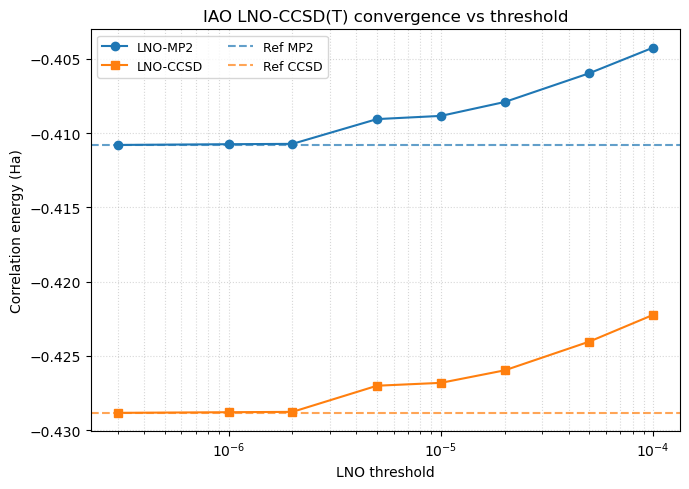

In [103]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Computed LNO values vs threshold
ax.plot(thresh_list, hz_emp2_tot,    'o-', color='tab:blue',   label='LNO-MP2')
ax.plot(thresh_list, hz_ecc_tot,   's-', color='tab:orange', label='LNO-CCSD')
# ax.plot(thresh_list, hz_orbmax, '^-', color='tab:green',  label='LNO-Size')

# Reference (full) values as horizontal dashed lines, color-matched
ax.axhline(efull_mp2,    ls='--', color='tab:blue',   alpha=0.7, label='Ref MP2')
ax.axhline(efull_ccsd,   ls='--', color='tab:orange', alpha=0.7, label='Ref CCSD')
# ax.axhline(efull_ccsd_t, ls='--', color='tab:green',  alpha=0.7, label='Ref CCSD(T)')

ax.set_xscale('log')
# ax.invert_xaxis()  # smaller threshold (tighter) on the right -> easier to read convergence
ax.set_xlabel('LNO threshold')
ax.set_ylabel('Correlation energy (Ha)')
ax.set_title('IAO LNO-CCSD(T) convergence vs threshold')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

In [104]:
# thresh_list = [1e-4,5e-5,2e-5,1e-5,5e-6,2e-6]
# ntest = len(thresh_list)
my_emp2_tot = np.zeros(ntest)
my_ecc_tot = np.zeros(ntest)
my_orbmax = np.zeros(ntest)

for i,thresh in enumerate(thresh_list):
    my_emp2_tot[i], my_ecc_tot[i], my_orbmax[i] \
        = my_lnoccsd(
            mf = mf,
            mp2t2 = mymp.t2,
            lo_coeff = iao_coeff, 
            frag_lolist = frag_lolist,
            nfrozen = mycc.frozen, 
            thresh = thresh, 
            run_frg_list = None,
            atom_group = moliao.elements
            )

Number of LNO-FRAGMENT: 6


=========================== RUNNING LNO-FRAGMENT 1/6 ===========================
Center Atom O
number of active occupied orbitals: 4
number of active virtual orbitals: 17
E(MODIFIED_CCSD) = -152.2725764523458  E_corr = -0.2100858054179962
LNO-MP2 Orbital Energy: -0.17758872
LNO-CCSD Orbital Energy: -0.17631005


=========================== RUNNING LNO-FRAGMENT 2/6 ===========================
Center Atom H
number of active occupied orbitals: 3
number of active virtual orbitals: 10
E(MODIFIED_CCSD) = -152.1984508058082  E_corr = -0.1359601588803842
LNO-MP2 Orbital Energy: -0.01458430
LNO-CCSD Orbital Energy: -0.01584946


=========================== RUNNING LNO-FRAGMENT 3/6 ===========================
Center Atom H
number of active occupied orbitals: 3
number of active virtual orbitals: 11
E(MODIFIED_CCSD) = -152.1977900318195  E_corr = -0.135299384891731
LNO-MP2 Orbital Energy: -0.01355621
LNO-CCSD Orbital Energy: -0.01446819


=========================== RUN

In [106]:
my_emp2_tot

array([-0.41330931, -0.42601422, -0.42976362, -0.43120716, -0.43669131,
       -0.43716925, -0.4373065 , -0.43768298])

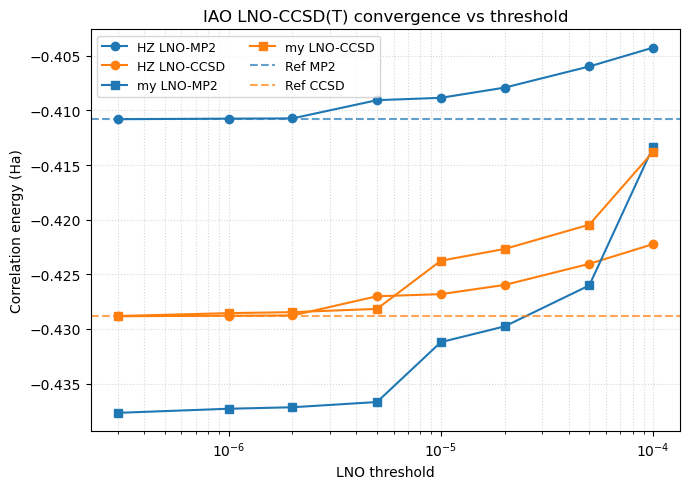

In [105]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Computed LNO values vs threshold
ax.plot(thresh_list, hz_emp2_tot,    'o-', color='tab:blue',   label='HZ LNO-MP2')
ax.plot(thresh_list, hz_ecc_tot,   'o-', color='tab:orange', label='HZ LNO-CCSD')

ax.plot(thresh_list, my_emp2_tot,    's-', color='tab:blue',   label='my LNO-MP2')
ax.plot(thresh_list, my_ecc_tot,   's-', color='tab:orange', label='my LNO-CCSD')
# ax.plot(thresh_list, hz_orbmax, '^-', color='tab:green',  label='LNO-Size')

# Reference (full) values as horizontal dashed lines, color-matched
ax.axhline(efull_mp2,    ls='--', color='tab:blue',   alpha=0.7, label='Ref MP2')
ax.axhline(efull_ccsd,   ls='--', color='tab:orange', alpha=0.7, label='Ref CCSD')
# ax.axhline(efull_ccsd_t, ls='--', color='tab:green',  alpha=0.7, label='Ref CCSD(T)')

ax.set_xscale('log')
# ax.invert_xaxis()  # smaller threshold (tighter) on the right -> easier to read convergence
ax.set_xlabel('LNO threshold')
ax.set_ylabel('Correlation energy (Ha)')
ax.set_title('IAO LNO-CCSD(T) convergence vs threshold')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

In [32]:
thresh_list = [1e-4]
ntest = len(thresh_list)
hz_emp2_tot = np.zeros(ntest)
hz_ecc_tot = np.zeros(ntest)
hz_orbmax = np.zeros(ntest)

for i,thresh in enumerate(thresh_list):
    hz_emp2_tot[i], hz_ecc_tot[i], hz_orbmax[i] \
        = hz_lnoccsd(
            mf = mf,
            lo_coeff = iao_coeff, 
            frag_lolist = frag_lolist,
            nfrozen = mycc.frozen, 
            thresh = thresh, 
            run_frg_list = None,
            atom_group = moliao.elements
            )

Number of LNO-FRAGMENT: 6


=========================== RUNNING LNO-FRAGMENT 1/6 ===========================
Center Atom O
lno active occ spans orbloc occ False
lno active vir spans orbloc vir False
lno active all spans orbloc all True
number of active occupied orbitals: 5
number of active virtual orbitals: 21
lno_frozen is [ 0  1  2  3  4 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
maskact is [False False False False False  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False False False False False
 False False False False False False False False False False False False]
E(MODIFIED_CCSD) = -152.2749162991162  E_corr = -0.2124256521883188
LNO-MP2 Orbital Energy: -0.17118303
LNO-CCSD Orbital Energy: -0.17846731


=========================== RUNNING LNO-FRAGMENT 2/6 ===========================
Center Atom H
lno active occ spans orbloc occ False
lno active vir spans orblo

In [41]:
my_emp2_tot = np.zeros(ntest)
my_ecc_tot = np.zeros(ntest)
my_orbmax = np.zeros(ntest)

for i,thresh in enumerate(thresh_list):
    my_emp2_tot[i], my_ecc_tot[i], my_orbmax[i] \
        = my_lnoccsd(
            mf = mf,
            mp2t2 = mymp.t2,
            lo_coeff = iao_coeff, 
            frag_lolist = frag_lolist,
            nfrozen = mycc.frozen, 
            thresh = 1e-7, 
            run_frg_list = None,
            atom_group = moliao.elements
            )

Number of LNO-FRAGMENT: 6


=========================== RUNNING LNO-FRAGMENT 1/6 ===========================
Center Atom O
lno active occ spans orbloc occ False
lno active vir spans orbloc vir False
lno active all spans orbloc all False
number of active occupied orbitals: 9
number of active virtual orbitals: 38
E(MODIFIED_CCSD) = -152.4890243164498  E_corr = -0.4265336695219343
LNO-MP2 Orbital Energy: -0.18207862
LNO-CCSD Orbital Energy: -0.17961816


=========================== RUNNING LNO-FRAGMENT 2/6 ===========================
Center Atom H
lno active occ spans orbloc occ False
lno active vir spans orbloc vir False
lno active all spans orbloc all False
number of active occupied orbitals: 9
number of active virtual orbitals: 29
E(MODIFIED_CCSD) = -152.4510537697813  E_corr = -0.3885631228534139
LNO-MP2 Orbital Energy: -0.01843487
LNO-CCSD Orbital Energy: -0.01790573


=========================== RUNNING LNO-FRAGMENT 3/6 ===========================
Center Atom H
lno active occ spans 

In [42]:
my_ecc_tot

array([-0.42883937])

In [43]:
mycc.e_corr

-0.42885000571354126